# Flight Delay Intelligence System — Exploratory Data Analysis
This notebook explores patterns in the processed dataset to understand delay drivers before feature engineering and modeling.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv(r"data/processed/flights_processed.csv")

In [8]:
df.shape

(2944078, 28)

In [9]:
df.head()

,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,...,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,MONTH,YEAR,DAY,DAY_OF_WEEK,ARR_DEL15
0,F9,407,DEN,LAX,17,1826.0,66.0,10.0,1836.0,1936.0,...,0.0,0.0,32.0,0.0,34.0,6,2014,14,5,1
1,WN,4704,CMH,BWI,15,1555.0,0.0,16.0,1611.0,1706.0,...,0.0,0.0,0.0,0.0,0.0,7,2014,21,0,0
2,AA,43,DTW,DFW,14,1456.0,6.0,11.0,1507.0,1628.0,...,0.0,0.0,0.0,0.0,0.0,10,2014,9,3,0
3,B6,1076,MCO,PVD,12,1239.0,-6.0,11.0,1250.0,1511.0,...,0.0,0.0,0.0,0.0,0.0,10,2014,27,0,0
4,WN,330,LAS,CLE,15,1545.0,20.0,9.0,1554.0,2225.0,...,0.0,0.0,0.0,0.0,0.0,4,2014,22,1,0


# Target variable distribution

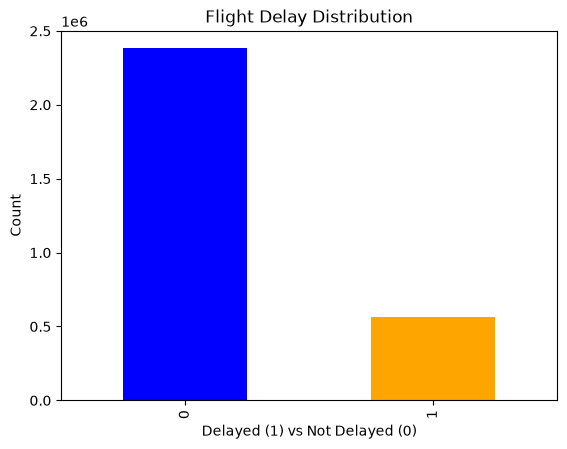

In [11]:
df['ARR_DEL15'].value_counts().plot(kind='bar', color=['blue','orange'])
plt.title('Flight Delay Distribution')
plt.xlabel('Delayed (1) vs Not Delayed (0)')
plt.ylabel('Count')
plt.show()

## Insights:
- ~2.4M on-time (0) vs ~550K delayed (1)
- 82% on-time, 18% delayed — class imbalance confirmed
- Imbalance is moderate, not severe — no resampling needed but must use F1/precision/recall as evaluation metrics, not accuracy

# ARR_DELAY distribution

<Axes: ylabel='Frequency'>

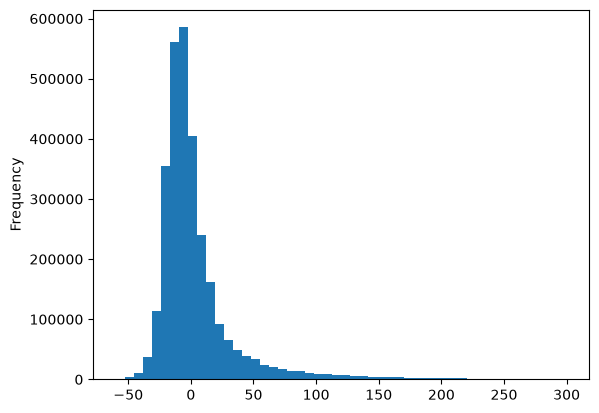

In [12]:
df[df['ARR_DELAY'].between(-60, 300)]['ARR_DELAY'].plot(kind='hist', bins=50)

# Airline performance
## Calculate delay rate per airline — percentage of flights delayed for each carrier.

In [13]:
df.groupby('OP_CARRIER')['ARR_DEL15'].mean().mul(100).round(2).sort_values(ascending=False)

OP_CARRIER
F9    24.87
B6    24.53
MQ    23.60
NK    22.67
VX    22.40
G4    22.24
EV    20.89
YV    20.78
OH    20.59
WN    20.41
AA    19.73
UA    19.21
9E    18.99
OO    18.62
YX    18.60
US    18.15
FL    17.33
AS    14.38
DL    13.94
HA     9.89
Name: ARR_DEL15, dtype: float64

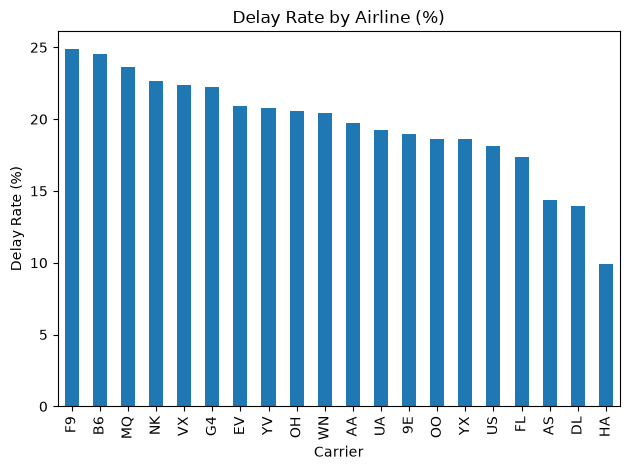

In [14]:
df.groupby('OP_CARRIER')['ARR_DEL15'].mean().mul(100).round(2).sort_values(ascending=False).plot(kind='bar')
plt.title('Delay Rate by Airline (%)')
plt.xlabel('Carrier')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

## Insights:
- Frontier (F9) worst at ~25% — budget carrier, tight turnarounds, one disruption cascades through the whole schedule.
- Hawaiian (HA) best at under 10% — but there's a catch: they fly isolated island routes with no connecting complexity, so it's partly geography not just operational excellence.
- Delta (DL) is the real standout — large mainline carrier, high volume, still only 14% delay rate. That's genuine operational efficiency.
- Southwest (WN) handles 21% of all flights in the dataset and sits at 20% — middle of the pack, acceptable at that scale.

# Top 20 airports by delay rate

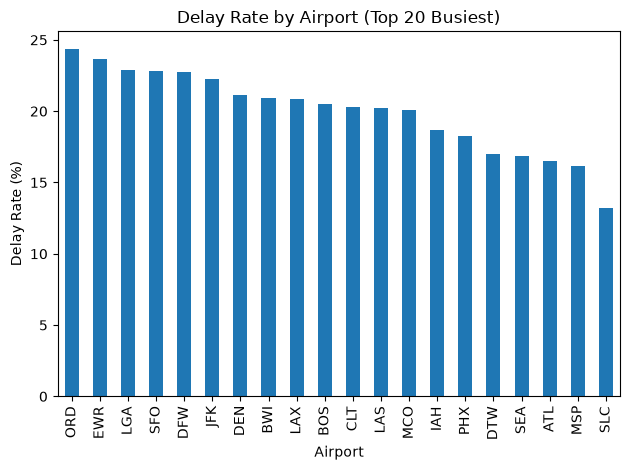

In [15]:
top20_airports = df.groupby('ORIGIN')['ARR_DEL15'].count().sort_values(ascending=False).head(20).index
df[df['ORIGIN'].isin(top20_airports)].groupby('ORIGIN')['ARR_DEL15'].mean().mul(100).round(2).sort_values(ascending=False).plot(kind='bar')
plt.title('Delay Rate by Airport (Top 20 Busiest)')
plt.xlabel('Airport')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

## Insights:
- ORD (Chicago O'Hare) worst with ~24.5% delay rate — known for weather and congestion issues
- EWR (Newark) second worst ~23.5% — notoriously congested New York area airspace
- LGA, SFO, DFW all above 22% — major hubs with high traffic volume
- SLC (Salt Lake City) best performer at ~13% among top 20 busiest — surprisingly efficient for its size
- ATL at ~16.5% — impressive given it's the busiest airport in the dataset (189K flights)

# Temporal patterns
### Plot delay rate by month:

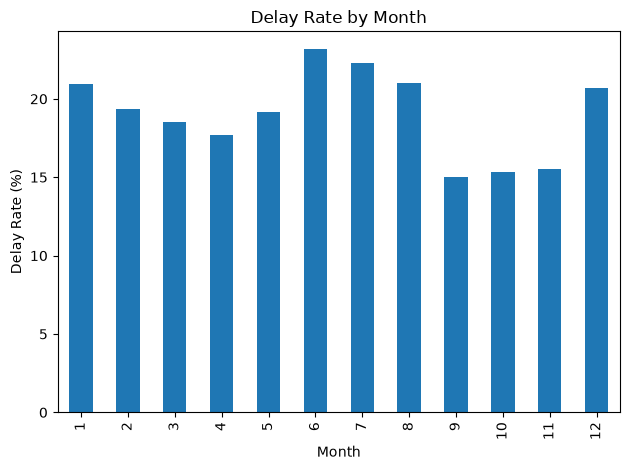

In [16]:
df.groupby('MONTH')['ARR_DEL15'].mean().mul(100).round(2).plot(kind='bar')
plt.title('Delay Rate by Month')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

## Insights:
- June (6) and July (7) are worst — ~23% and ~22% delay rates — summer travel peak + thunderstorm season
- August (8) still elevated at ~21% — summer effect continues
- September (9) is the best month — ~15% delay rate, post-summer lull, pre-winter
- October, November also low ~15-16% — fall is the best season to fly
- December (12) spikes back up — holiday travel + winter weather
- January (1) elevated at ~21% — winter storms
- Clear U-shape pattern: delays peak in summer and winter, drop in fall

# Delay rate by day of week

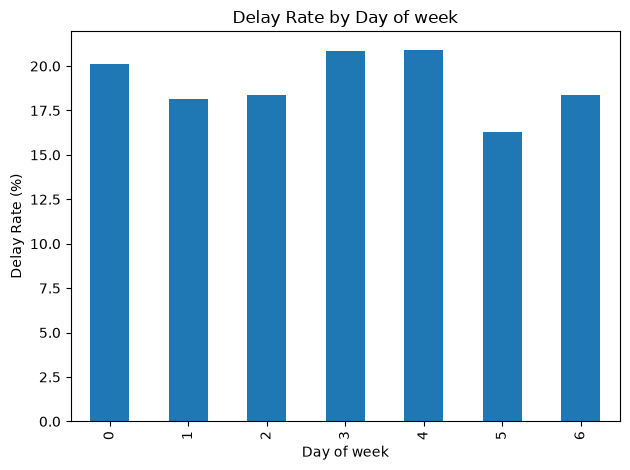

In [17]:
df.groupby('DAY_OF_WEEK')['ARR_DEL15'].mean().mul(100).round(2).plot(kind='bar')
plt.title('Delay Rate by Day of week')
plt.xlabel('Day of week')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

## Insights:
- Thursday (3) and Friday (4) are worst — ~21% delay rate — end of week travel surge, cascading delays build up through the week
- Saturday (5) is the best day to fly — ~16.5% — fewer business travelers, less congestion
- Monday (0) elevated at ~20% — start of week business travel
- Tuesday, Wednesday relatively low ~18% — mid-week is safer
- Sunday (6) moderate ~18.5% — return travel but not as bad as Friday

# Delay rate by departure hour

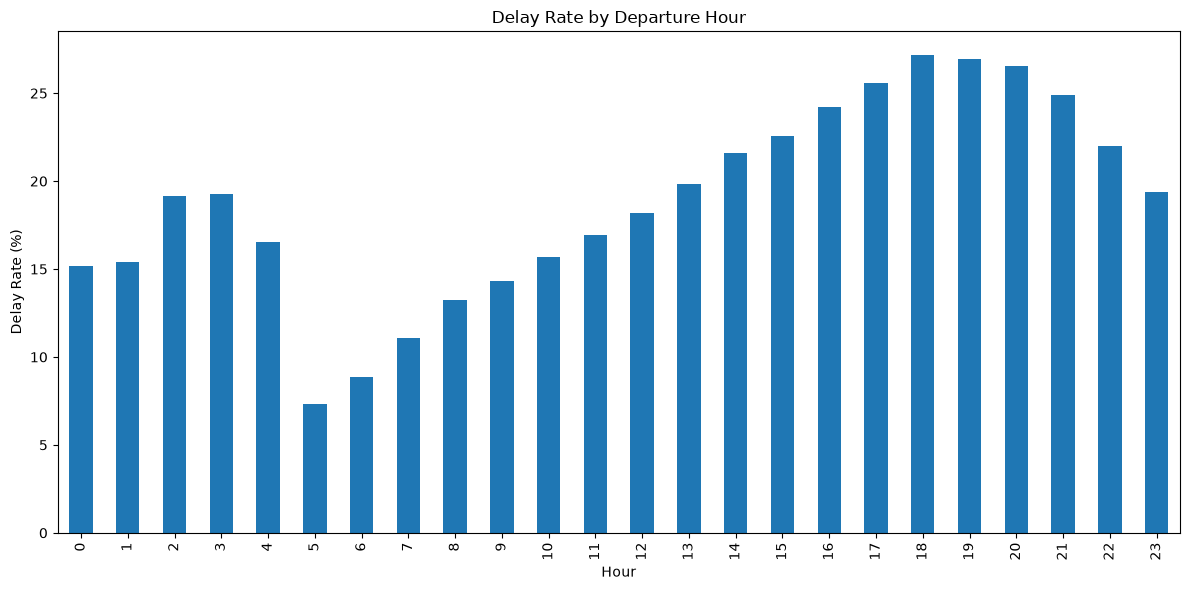

In [19]:
plt.figure(figsize=(12,6))
df.groupby('CRS_DEP_TIME')['ARR_DEL15'].mean().mul(100).round(2).plot(kind='bar')
plt.title('Delay Rate by Departure Hour')
plt.xlabel('Hour')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

## Insights:
- 5 AM is the best time to fly — only ~7% delay rate — aircraft are fresh, no cascading delays yet
- 6 AM also low — ~9% — early morning flights are consistently most reliable
- Clear upward trend through the day — delays accumulate as the day progresses
- 6 PM to 9 PM (18–21) are worst — ~27% delay rate — peak evening congestion, every earlier delay has cascaded
- Late night (22–23) improves slightly — fewer flights, less congestion
- Midnight flights (0–3) elevated — likely delayed flights from earlier in the day finally departing

# Delay cause breakdown
### What causes delays the most? Calculate total minutes per cause:

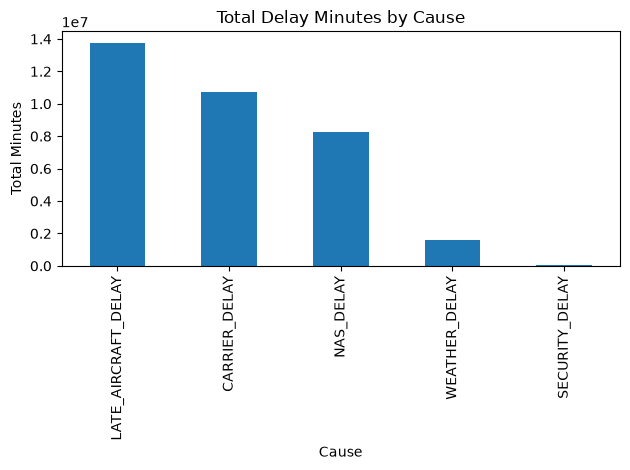

In [20]:
causes = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[causes].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Delay Minutes by Cause')
plt.xlabel('Cause')
plt.ylabel('Total Minutes')
plt.tight_layout()
plt.show()

## Insights:
- LATE_AIRCRAFT_DELAY is the biggest cause — ~137M minutes total — a late incoming aircraft causes the next flight to be late, cascading effect throughout the day
- CARRIER_DELAY second — ~107M minutes — airline operational issues (maintenance, crew, fueling)
- NAS_DELAY third — ~82M minutes — air traffic control, airport operations, heavy traffic
- WEATHER_DELAY surprisingly low — ~15M minutes — weather causes fewer delays than people think, but when it hits it's severe
- SECURITY_DELAY negligible — barely visible — extremely rare

# Correlation heatmap

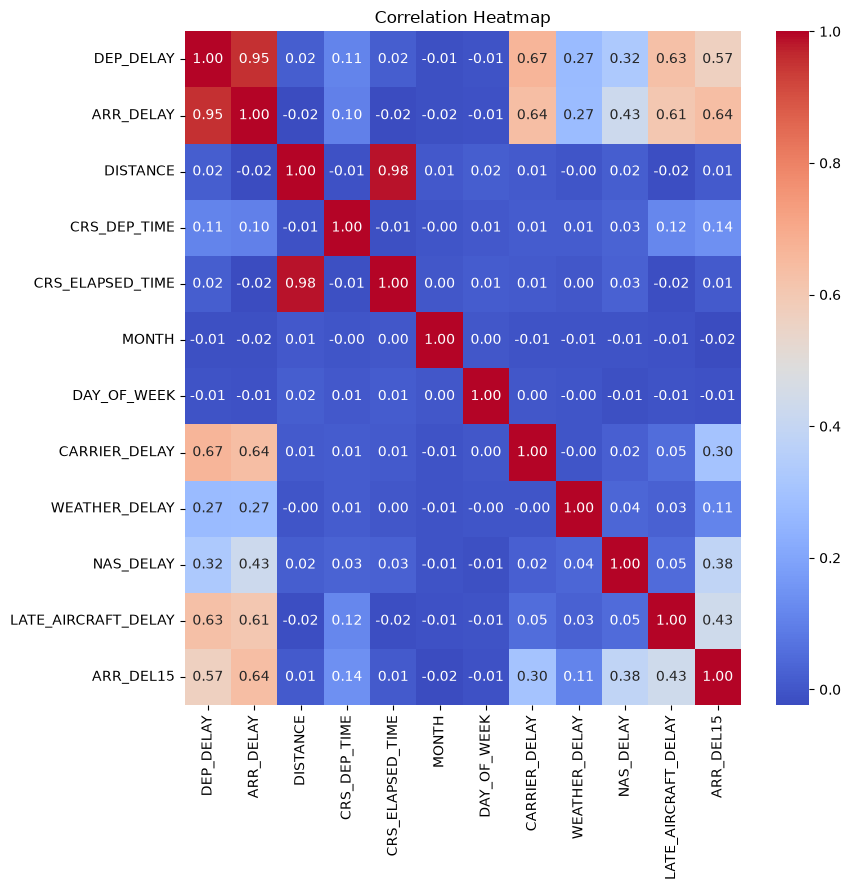

In [25]:
plt.figure(figsize=(9,9))
cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CRS_DEP_TIME', 'CRS_ELAPSED_TIME',
        'MONTH', 'DAY_OF_WEEK', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 
        'LATE_AIRCRAFT_DELAY', 'ARR_DEL15']

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Insights:
- DEP_DELAY vs ARR_DELAY: 0.95 — strongest correlation in the entire dataset. If a flight departs late, it almost certainly arrives late. Most important predictor but cannot be used as a feature — it's data leakage (you won't know departure delay before the flight departs in a real prediction scenario)
- LATE_AIRCRAFT_DELAY vs ARR_DEL15: 0.43 — strongest delay cause correlation with target, confirms Q8 finding
- NAS_DELAY vs ARR_DEL15: 0.38 — second strongest cause
- CARRIER_DELAY vs ARR_DEL15: 0.30 — third
- DISTANCE vs CRS_ELAPSED_TIME: 0.98 — near perfect, expected — longer distance = longer flight time. One of these is redundant, drop one in feature engineering
- MONTH, DAY_OF_WEEK: near zero correlation — low linear correlation but we saw clear patterns in bar charts — non-linear relationship, tree models will capture this

## EDA Summary & Feature Engineering Implications
- Drop DEP_DELAY, ARR_DELAY from features — data leakage
- Drop CRS_ELAPSED_TIME — redundant with DISTANCE (0.98 correlation)
- Strong features: CRS_DEP_TIME, MONTH, DAY_OF_WEEK, OP_CARRIER, ORIGIN, DEST, DISTANCE
- MONTH and DAY_OF_WEEK show non-linear patterns — tree models will handle this well
- Next: 04_feature_engineering.ipynb